# Introduction to Analytical Tables

The cron process makes a number of tables available for analysis. These tables are updated at the beginning of each day. 

| Table      | Description      |
| ------------- | ------------- |
| sensor_readings | The most "raw" data from the Coris API. One row per Sensor and UTC timestamp. Devices have 2 Sensors, one for Temperature and one for Humidity so each Device will typically have two rows per UTC timestamp. |
| device_readings | Sensor readings reorganized to one row per Device and UTC timestamp, with Sensor measurements across columns instead of rows. |
| sensors | Information about the unique sensors. One row per SensorID_Coris. Includes information extracted from SensorName. Join this to sensor_readings during analysis to enhance with Building, Room, Direction, etc. |
| devices | Information about unique devices. One row per DeviceID_Coris. Includes information extracted from SensorName. Join this to device_readings during analysis to enhance with Building, Room, Direction, etc. |
| utcs | Information related to the UTC times in various datasets. Join to sensor_readings or device_readings to enhance with Date, Time, Year, Hour, Weekday, etc. |
| sensor_readings_daily | Example of sensor readings summarized to the daily level which reduces row count by 99.3% for even faster queries. You can create different cubes to support common analysis patterns. |
| device_readings_daily | Example of device readings summarized to the daily level. |

Let's take a look at each of the tables. 

In [1]:
import duckdb
duckdb.sql("SELECT * FROM read_parquet('../data/sensor_readings.parquet') LIMIT 5").df()

,SensorReadingUTC,QueryUTC,Source,DeviceID,DeviceName,SensorID,SensorName,SensorType,SensorReadingF,SensorReadingRh,SensorReadingUTC_SecondsFromPrior,Historical
0,1763926933,1764531482,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH,BYCBA_0400410__N____ - RH,RH,NaN,50.020000,<NA>,True
1,1763927833,1764531482,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH,BYCBA_0400410__N____ - RH,RH,NaN,49.299999,<NA>,True
2,1763928733,1764531482,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH,BYCBA_0400410__N____ - RH,RH,NaN,48.529999,<NA>,True
3,1763929633,1764531482,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH,BYCBA_0400410__N____ - RH,RH,NaN,49.029999,<NA>,True
4,1763930533,1764531482,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH,BYCBA_0400410__N____ - RH,RH,NaN,48.919998,<NA>,True


In [2]:
duckdb.sql("""
    SELECT * 
    FROM read_parquet('../data/sensor_readings.parquet') 
    WHERE Historical = false AND SensorID = 'conserv:333:c008706:RH'
""").df()

,SensorReadingUTC,QueryUTC,Source,DeviceID,DeviceName,SensorID,SensorName,SensorType,SensorReadingF,SensorReadingRh,SensorReadingUTC_SecondsFromPrior,Historical
0,1764531737,1764532512,Conserv,conserv:333:c008706,BYCBA_0400410__N____,conserv:333:c008706:RH,BYCBA_0400410__N____ - RH,RH,NaN,48.040001,<NA>,False


In [3]:
duckdb.sql("SELECT * FROM read_parquet('../data/device_readings.parquet') LIMIT 5").df()

,Source,DeviceID,DeviceName,Sensors,SensorNames,SensorTypes,SensorReadingUTC,QueryUTC,Historical,SensorReadingF,SensorReadingRh
0,Conserv,conserv:333:c008706,BYCBA_0400410__N____,"conserv:333:c008706:RH, conserv:333:c008706:Te...","BYCBA_0400410__N____ - RH, BYCBA_0400410__N___...","RH, Temperature",1763926933,1764531482,True,69.529999,50.020000
1,Conserv,conserv:333:c008706,BYCBA_0400410__N____,"conserv:333:c008706:RH, conserv:333:c008706:Te...","BYCBA_0400410__N____ - RH, BYCBA_0400410__N___...","RH, Temperature",1763927833,1764531482,True,69.386002,49.299999
2,Conserv,conserv:333:c008706,BYCBA_0400410__N____,"conserv:333:c008706:RH, conserv:333:c008706:Te...","BYCBA_0400410__N____ - RH, BYCBA_0400410__N___...","RH, Temperature",1763928733,1764531482,True,69.313995,48.529999
3,Conserv,conserv:333:c008706,BYCBA_0400410__N____,"conserv:333:c008706:RH, conserv:333:c008706:Te...","BYCBA_0400410__N____ - RH, BYCBA_0400410__N___...","RH, Temperature",1763929633,1764531482,True,69.332001,49.029999
4,Conserv,conserv:333:c008706,BYCBA_0400410__N____,"conserv:333:c008706:RH, conserv:333:c008706:Te...","BYCBA_0400410__N____ - RH, BYCBA_0400410__N___...","RH, Temperature",1763930533,1764531482,True,69.458000,48.919998


In [4]:
duckdb.sql("SELECT * FROM read_parquet('../data/sensors.parquet') LIMIT 5").df()

,Source,SensorID,SensorName,SensorType,DeviceID,DeviceSerialFromName,BuildingID,Building,Room,CardinalDirection,DeviceName,SensorReadingUTC,QueryUTC,Historical
0,LI-COR,licor:10740550-10740550-2,ICSC__010C149________RH,RH,licor:10740550,RH,FLOATER,Unknown,FLOATER,None,ICSC__010C149_______,1764532625,1764532625,False
1,LI-COR,licor:10740550-10740550-1,ICSC__010C149________Temperature,Temperature,licor:10740550,Temperature,FLOATER,Unknown,FLOATER,None,ICSC__010C149_______,1764532625,1764532625,False
2,Coris,coris:21378,RH KGL 21_D0B2,Humidity,coris:12167,D0B2,KGL,Kline Geology Laboratory,21,Not Indicated,Peabody TH-L Upper Great Hall D0B2,1764110282,1764531605,True
3,Coris,coris:21378,RH KGL 21_D0B2,Humidity,coris:12167,D0B2,KGL,Kline Geology Laboratory,21,Not Indicated,Peabody TH-L Upper Great Hall D0B2,1764174182,1764531605,True
4,Coris,coris:21378,RH KGL 21_D0B2,Humidity,coris:12167,D0B2,KGL,Kline Geology Laboratory,21,Not Indicated,Peabody TH-L Upper Great Hall D0B2,1764145382,1764531605,True


In [5]:
duckdb.sql("SELECT * FROM read_parquet('../data/devices.parquet') LIMIT 5").df()

,Source,DeviceID,DeviceName,Sensors,SensorNames,SensorTypes,DeviceSerialFromName,BuildingID,Building,Room,CardinalDirection
0,LI-COR,licor:10740550,ICSC__010C149_______,"licor:10740550-10740550-2, licor:10740550-1074...","ICSC__010C149________RH, ICSC__010C149________...","RH, Temperature",RH,FLOATER,Unknown,FLOATER,None
1,Coris,coris:12167,Peabody TH-L Upper Great Hall D0B2,"coris:21378, coris:21378, coris:21378, coris:2...","RH KGL 21_D0B2, RH KGL 21_D0B2, RH KGL 21_D0B2...","Humidity, Humidity, Humidity, Humidity, Humidi...",D0B2,KGL,Kline Geology Laboratory,21,Not Indicated
2,Conserv,conserv:333:c009072,BBARCH0100001_______,"conserv:333:c009072:RH, conserv:333:c009072:RH...","- RH, - RH, - RH, - RH, - RH, - RH, - RH, - RH...","RH, RH, RH, RH, RH, RH, RH, RH, RH, RH, RH, RH...",None,MALFORMED,Unknown,Unknown,None
3,Conserv,conserv:333:c009073,BBARCHB100116_______,"conserv:333:c009073:RH, conserv:333:c009073:RH...","- RH, - RH, - RH, - RH, - RH, - RH, - RH, - RH...","RH, RH, RH, RH, RH, RH, RH, RH, RH, RH, RH, RH...",None,MALFORMED,Unknown,Unknown,None
4,Conserv,conserv:333:c009081,BCSC__01H103________,"conserv:333:c009081:RH, conserv:333:c009081:RH...","- RH, - RH, - RH, - RH, - RH, - RH, - RH, - RH...","RH, RH, RH, RH, RH, RH, RH, RH, RH, RH, RH, RH...",None,MALFORMED,Unknown,Unknown,None


In [6]:
duckdb.sql("SELECT * FROM read_parquet('../data/utcs.parquet') LIMIT 5").df()

,UTC,datetime_utc,datetime_est,date,time,year,month,day_of_week,day_of_week_monday1_sunday7,hour_24,hour_12,am_pm
0,1764098049,2025-11-25 12:14:09,2025-11-25 05:14:09-07:00,2025-11-25,07:14:09,2025,11,Tuesday,2,7,7,AM
1,1763966981,2025-11-23 23:49:41,2025-11-23 16:49:41-07:00,2025-11-23,18:49:41,2025,11,Sunday,7,18,6,PM
2,1764360204,2025-11-28 13:03:24,2025-11-28 06:03:24-07:00,2025-11-28,08:03:24,2025,11,Friday,5,8,8,AM
3,1764229133,2025-11-27 00:38:53,2025-11-26 17:38:53-07:00,2025-11-26,19:38:53,2025,11,Wednesday,3,19,7,PM
4,1764229143,2025-11-27 00:39:03,2025-11-26 17:39:03-07:00,2025-11-26,19:39:03,2025,11,Wednesday,3,19,7,PM


In [7]:
duckdb.sql("SELECT * FROM read_parquet('../data/sensor_readings_daily.parquet') LIMIT 5").df()

,Source,date,SensorID,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
0,Conserv,2025-11-30,conserv:333:c008733:RH,1,0.000000,44.939999,NaN,44.939999,NaN,44.939999
1,Conserv,2025-11-30,conserv:333:c008733:Temperature,1,70.016006,0.000000,70.016006,NaN,70.016006,NaN
2,Conserv,2025-11-30,conserv:333:c008781:RH,2,0.000000,93.449997,NaN,46.520000,NaN,46.930000
3,Conserv,2025-11-30,conserv:333:c008781:Temperature,2,140.067993,0.000000,69.998001,NaN,70.070000,NaN
4,Conserv,2025-11-30,conserv:333:c008784:RH,1,0.000000,44.820000,NaN,44.820000,NaN,44.820000


In [8]:
duckdb.sql("SELECT * FROM read_parquet('../data/device_readings_daily.parquet') LIMIT 5").df()

,Source,date,DeviceID,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
0,Conserv,2025-11-30,conserv:333:c008733,1,70.016006,44.939999,70.016006,44.939999,70.016006,44.939999
1,Conserv,2025-11-30,conserv:333:c008781,2,140.067993,93.449997,69.998001,46.520000,70.070000,46.930000
2,Conserv,2025-11-30,conserv:333:c008784,1,69.926003,44.820000,69.926003,44.820000,69.926003,44.820000
3,Conserv,2025-11-30,conserv:333:c008924,1,69.656006,45.599998,69.656006,45.599998,69.656006,45.599998
4,Conserv,2025-11-30,conserv:333:c008949,2,138.628006,90.610001,69.296005,45.119999,69.332001,45.490002


# Sample Queries

<Axes: xlabel='Weekday', ylabel='Mean SensorReadingF'>

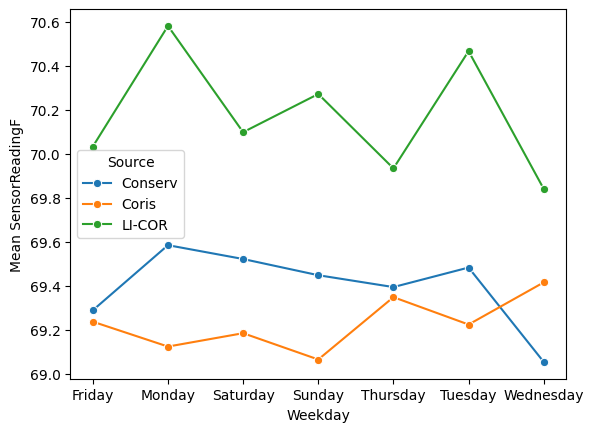

In [9]:
# Example: Average reading by Weekday. 

# join utcs to get weekday. 
# df converts results to a pandas DataFrame.

# use abs(dr.SensorReadingUTC - dr.QueryUTC) < 60 * 5 to remove old sensor readings.

import seaborn as sns

data = duckdb.sql("""
    SELECT day_of_week as Weekday, Source, avg(SensorReadingF) as 'Mean SensorReadingF'
    FROM read_parquet('../data/device_readings.parquet') AS dr
    INNER JOIN read_parquet('../data/utcs.parquet') AS u ON 
        dr.SensorReadingUTC = u.UTC
    GROUP BY day_of_week, Source
    ORDER BY day_of_week, Source
""").df()

sns.lineplot(x='Weekday', y='Mean SensorReadingF', hue='Source', data=data, marker='o')

<Axes: xlabel='Weekday', ylabel='Mean SensorReadingF'>

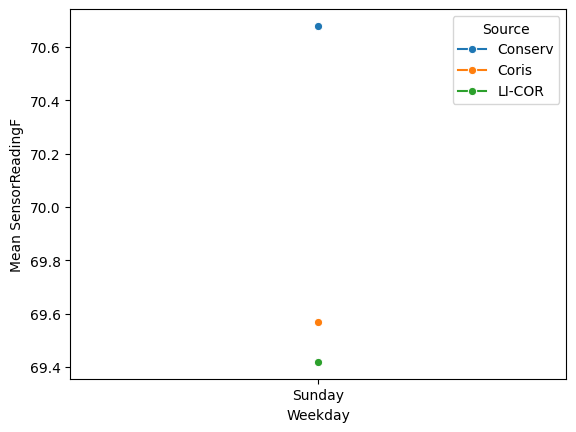

In [10]:
# Example: Average reading by Weekday - using the cubes.

# join utcs to get weekday. 
# df converts results to a pandas DataFrame.

# cubes already have old sensor readings removed. 

import seaborn as sns

data = duckdb.sql("""
    SELECT day_of_week as Weekday, Source, sum(SensorReadingF_sum) / sum(row_count) as 'Mean SensorReadingF'
    FROM read_parquet('../data/device_readings_daily.parquet') AS drd
    INNER JOIN (SELECT DISTINCT date, day_of_week FROM read_parquet('../data/utcs.parquet')) AS u
        ON drd.date = u.date
    GROUP BY day_of_week, Source
    ORDER BY day_of_week, Source
""").df()

# need DISTINCT on utcs to prevent duplication!

sns.lineplot(x='Weekday', y='Mean SensorReadingF', hue='Source', data=data, marker='o')

In [11]:
# Buildings: Number of Devices, First Reading.

# join utcs to get date. 
# join devices to get building info.
# df converts results to a pandas DataFrame.

duckdb.sql("""
    SELECT dr.Source, Building, min(date) as 'First Reading', count(DISTINCT dr.DeviceID) as 'Count of Devices'
    FROM read_parquet('../data/device_readings.parquet') AS dr
    INNER JOIN read_parquet('../data/utcs.parquet') AS u
        ON dr.SensorReadingUTC = u.UTC
    INNER JOIN read_parquet('../data/devices.parquet') AS d
        ON d.DeviceID = dr.DeviceID
    GROUP BY dr.Source, Building
    ORDER BY min(date)
""").df()

,Source,Building,First Reading,Count of Devices
0,LI-COR,Unknown,2025-11-23,3
1,Coris,Yale Peabody Museum,2025-11-23,2
2,Coris,Kline Geology Laboratory,2025-11-23,1
3,Conserv,Unknown,2025-11-23,30


In [13]:
# Readings that differ from the Query UTC. These could be data errors if the difference is large.
duckdb.sql("""
    SELECT QueryUTC, SensorReadingUTC, (SensorReadingUTC - QueryUTC) / 60 as 'Difference (Minutes)'
    FROM read_parquet('../data/sensor_readings.parquet') 
    WHERE abs(SensorReadingUTC - QueryUTC) > 60 * 1 AND Historical = False
    ORDER BY abs(SensorReadingUTC - QueryUTC) DESC
""").df()

,QueryUTC,SensorReadingUTC,Difference (Minutes)
0,1764532512,1764531653,-14.316667
1,1764532512,1764531653,-14.316667
2,1764532512,1764531659,-14.216667
3,1764532512,1764531659,-14.216667
4,1764532512,1764531675,-13.950000
5,1764532512,1764531675,-13.950000
6,1764532512,1764531710,-13.366667
7,1764532512,1764531710,-13.366667
8,1764532512,1764531737,-12.916667
9,1764532512,1764531737,-12.916667
